In [ ]:
from pathlib import Path

import h2o
import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from h2o.automl import H2OAutoML

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/ridership_headline.parquet")
TARGET = "rail_mrt_kajang"
RANDOM_STATE = 42

In [4]:
h2o.init(
    nthreads=-1,
    max_mem_size="8G",
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 25.501-b08, mixed mode)
  Starting server from D:\GitHub\mlops-rapidkl-v2\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\user1\AppData\Local\Temp\tmph7jftmqh
  JVM stdout: C:\Users\user1\AppData\Local\Temp\tmph7jftmqh\h2o_user1_started_from_python.out
  JVM stderr: C:\Users\user1\AppData\Local\Temp\tmph7jftmqh\h2o_user1_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Asia/Singapore
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.12
H2O_cluster_version_age:,2 days
H2O_cluster_name:,H2O_from_python_user1_om400b
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.088 Gb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"



+------------------------------------------------------------------+
| You are running the community edition of H2O-3 OSS.              |
|                                                                  |
| For commercial use, H2O-3 Secure is now recommended.             |
| This includes production support, CVE fixes, multi-node scaling, |
| model artifact extraction, and more.                             |
| See h2o.ai/h2o-3/oss-vs-secure for additional details.           |
| Contact enterprise@h2o.ai to upgrade.                            |
+------------------------------------------------------------------+


In [8]:
df = pd.read_parquet(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
    .set_index("date")
)

model_data = df[[TARGET]].copy()
model_data[TARGET] = model_data[TARGET].astype("float64")

print("Shape:", model_data.shape)
print("Date range:", model_data.index.min(), "to", model_data.index.max())

display(model_data.head())

Shape: (2738, 1)
Date range: 2019-01-01 00:00:00 to 2026-06-30 00:00:00


,rail_mrt_kajang
date,
2019-01-01,114173.0
2019-01-02,169316.0
2019-01-03,175304.0
2019-01-04,187891.0
2019-01-05,112660.0


In [9]:
assert isinstance(model_data.index, pd.DatetimeIndex)
assert model_data.index.is_monotonic_increasing
assert not model_data.index.has_duplicates
assert model_data[TARGET].notna().all()
assert model_data[TARGET].ge(0).all()

print("Data validation passed.")

Data validation passed.


In [10]:
model_data["day_of_week"] = model_data.index.dayofweek
model_data["month"] = model_data.index.month
model_data["year"] = model_data.index.year

model_data["is_weekend"] = (
    model_data.index.dayofweek >= 5
).astype("int8")

In [11]:
years = range(
    model_data.index.min().year,
    model_data.index.max().year + 1,
)

holiday_calendars = {
    "kul": holidays.country_holidays(
        "MY",
        subdiv="KUL",
        years=years,
        observed=True,
    ),
    "sgr": holidays.country_holidays(
        "MY",
        subdiv="SGR",
        years=years,
        observed=True,
    ),
    "pjy": holidays.country_holidays(
        "MY",
        subdiv="PJY",
        years=years,
        observed=True,
    ),
}

dates = pd.Series(
    model_data.index.date,
    index=model_data.index,
)

regional_holiday_columns = []

for region, calendar in holiday_calendars.items():
    column = f"is_holiday_{region}"

    model_data[column] = (
        dates.isin(calendar)
        .astype("int8")
    )

    regional_holiday_columns.append(column)

model_data["is_public_holiday"] = (
    model_data[regional_holiday_columns]
    .max(axis=1)
    .astype("int8")
)

holiday = model_data["is_public_holiday"].astype(bool)

model_data["is_day_before_holiday"] = (
    holiday
    .shift(-1, fill_value=False)
    .astype("int8")
)

model_data["is_day_after_holiday"] = (
    holiday
    .shift(1, fill_value=False)
    .astype("int8")
)

In [12]:
display(
    model_data.loc[
        model_data["is_public_holiday"].eq(1),
        regional_holiday_columns
        + ["is_public_holiday", TARGET],
    ].head(20)
)

,is_holiday_kul,is_holiday_sgr,is_holiday_pjy,is_public_holiday,rail_mrt_kajang
date,,,,,
2019-01-01,1,1,1,1,114173.0
2019-01-21,1,1,1,1,106077.0
2019-02-01,1,0,1,1,134808.0
2019-02-05,1,1,1,1,98115.0
2019-02-06,1,1,1,1,91478.0
2019-05-01,1,1,1,1,135733.0
2019-05-19,1,1,1,1,94901.0
2019-05-20,1,1,1,1,92033.0
2019-05-22,1,1,1,1,97824.0


In [13]:
model_data["lag_1"] = model_data[TARGET].shift(1)
model_data["lag_7"] = model_data[TARGET].shift(7)
model_data["lag_14"] = model_data[TARGET].shift(14)
model_data["lag_28"] = model_data[TARGET].shift(28)

In [14]:
past_target = model_data[TARGET].shift(1)

model_data["rolling_mean_7"] = (
    past_target.rolling(window=7).mean()
)

model_data["rolling_mean_28"] = (
    past_target.rolling(window=28).mean()
)

model_data["rolling_std_7"] = (
    past_target.rolling(window=7).std()
)

In [15]:
FEATURE_COLUMNS = [
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "is_holiday_kul",
    "is_holiday_sgr",
    "is_holiday_pjy",
    "is_public_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_7",
]

In [16]:
train = model_data.loc[:"2024-12-31"].copy()

validation = model_data.loc[
    "2025-01-01":"2025-12-31"
].copy()

test = model_data.loc["2026-01-01":].copy()

assert not train.empty
assert not validation.empty
assert not test.empty

In [17]:
for name, split in {
    "Train": train,
    "Validation": validation,
    "Test": test,
}.items():
    print(
        f"{name}: "
        f"{split.index.min().date()} to "
        f"{split.index.max().date()} "
        f"({len(split):,} rows)"
    )

Train: 2019-01-01 to 2024-12-31 (2,192 rows)
Validation: 2025-01-01 to 2025-12-31 (365 rows)
Test: 2026-01-01 to 2026-06-30 (181 rows)


In [18]:
h2o_columns = FEATURE_COLUMNS + [TARGET]

train_h2o = h2o.H2OFrame(
    train[h2o_columns].reset_index(drop=True)
)

validation_h2o = h2o.H2OFrame(
    validation[h2o_columns].reset_index(drop=True)
)

test_h2o = h2o.H2OFrame(
    test[h2o_columns].reset_index(drop=True)
)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [19]:
CATEGORICAL_FEATURES = [
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday_kul",
    "is_holiday_sgr",
    "is_holiday_pjy",
    "is_public_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
]

for column in CATEGORICAL_FEATURES:
    train_h2o[column] = train_h2o[column].asfactor()
    validation_h2o[column] = validation_h2o[column].asfactor()
    test_h2o[column] = test_h2o[column].asfactor()

In [20]:
print(train_h2o.types)

{'day_of_week': 'enum', 'month': 'enum', 'year': 'int', 'is_weekend': 'enum', 'is_holiday_kul': 'enum', 'is_holiday_sgr': 'enum', 'is_holiday_pjy': 'enum', 'is_public_holiday': 'enum', 'is_day_before_holiday': 'enum', 'is_day_after_holiday': 'enum', 'lag_1': 'int', 'lag_7': 'int', 'lag_14': 'int', 'lag_28': 'int', 'rolling_mean_7': 'real', 'rolling_mean_28': 'real', 'rolling_std_7': 'real', 'rail_mrt_kajang': 'int'}


In [22]:
print("Train:", train_h2o.shape)
print("Validation:", validation_h2o.shape)
print("Test:", test_h2o.shape)

Train: (2192, 18)
Validation: (365, 18)
Test: (181, 18)


In [23]:
automl = H2OAutoML(
    max_models=20,
    seed=RANDOM_STATE,
    sort_metric="MAE",
    stopping_metric="MAE",
    nfolds=0,
    exclude_algos=["DeepLearning"],
    keep_cross_validation_predictions=False,
)

automl.train(
    x=FEATURE_COLUMNS,
    y=TARGET,
    training_frame=train_h2o,
    validation_frame=validation_h2o,
    leaderboard_frame=validation_h2o,
)

AutoML progress: |
22:42:20.321: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%


,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
,65.0,65.0,100157.0,9.0,9.0,9.0,24.0,177.0,117.96923
,timestamp,duration,number_of_trees,training_rmse,training_mae,training_deviance,validation_rmse,validation_mae,validation_deviance
,2026-08-13 22:42:25,1.337 sec,0.0,73408.7204399,63873.6690724,5388840236.6213179,120564.7596949,111282.2451367,14535861280.2828979
,2026-08-13 22:42:26,1.360 sec,5.0,44231.2970430,38317.5023416,1956407638.1061180,75033.6281386,67927.4566739,5630045351.6434355
,2026-08-13 22:42:26,1.382 sec,10.0,27030.1023998,23345.9134227,730626435.7458242,49847.4536270,44466.4356942,2484768633.0927625
,2026-08-13 22:42:26,1.403 sec,15.0,16935.5799791,14422.5765907,286813869.2287169,34515.8583001,30294.1051674,1191344474.1896851
,2026-08-13 22:42:26,1.422 sec,20.0,11305.8942655,9296.9997158,127823245.1434574,26826.0665524,23207.9491736,719637846.6718358
,2026-08-13 22:42:26,1.441 sec,25.0,8107.6733856,6255.9920271,65734367.7278188,22907.9624154,19364.0390203,524774742.0233728
,2026-08-13 22:42:26,1.458 sec,30.0,6414.4713533,4531.6416434,41145442.7424038,20036.0713453,16104.5317316,401444154.9521661
,2026-08-13 22:42:26,1.474 sec,35.0,5419.5166627,3525.4757982,29371160.8575180,18652.5114406,14228.3299734,347916183.0415502


In [24]:
leaderboard = automl.leaderboard.as_data_frame()

display(leaderboard)

d:\GitHub\mlops-rapidkl-v2\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,mae,rmse,mse,rmsle,mean_residual_deviance
0,GBM_grid_1_AutoML_1_20260813_224220_model_5,12749.855537,17473.809677,3.053340e+08,0.073342,3.053340e+08
1,GBM_grid_1_AutoML_1_20260813_224220_model_4,13440.358519,17151.600155,2.941774e+08,0.070490,2.941774e+08
2,GBM_3_AutoML_1_20260813_224220,13729.145293,18628.761223,3.470307e+08,0.078839,3.470307e+08
3,GBM_grid_1_AutoML_1_20260813_224220_model_2,14267.274244,19301.326944,3.725412e+08,0.081443,3.725412e+08
4,DRF_1_AutoML_1_20260813_224220,14406.651037,19144.204507,3.665006e+08,0.080193,3.665006e+08
5,GBM_4_AutoML_1_20260813_224220,14828.626031,20064.370022,4.025789e+08,0.085486,4.025789e+08
6,GBM_grid_1_AutoML_1_20260813_224220_model_11,15153.581332,19952.801797,3.981143e+08,0.084410,3.981143e+08
7,GBM_grid_1_AutoML_1_20260813_224220_model_9,15477.526673,20343.221856,4.138467e+08,0.085738,4.138467e+08
8,GBM_2_AutoML_1_20260813_224220,15597.095265,21139.016075,4.468580e+08,0.090280,4.468580e+08
9,XRT_1_AutoML_1_20260813_224220,15599.911224,21752.145847,4.731558e+08,0.092033,4.731558e+08


In [25]:
leaderboard_columns = [
    column
    for column in [
        "model_id",
        "mae",
        "rmse",
        "mse",
        "rmsle",
        "mean_residual_deviance",
    ]
    if column in leaderboard.columns
]

display(
    leaderboard[leaderboard_columns]
    .head(10)
    .style.format({
        "mae": "{:,.0f}",
        "rmse": "{:,.0f}",
        "mse": "{:,.0f}",
        "rmsle": "{:.4f}",
        "mean_residual_deviance": "{:,.0f}",
    })
)

,model_id,mae,rmse,mse,rmsle,mean_residual_deviance
0,GBM_grid_1_AutoML_1_20260813_224220_model_5,"12,750","17,474","305,334,025",0.0733,"305,334,025"
1,GBM_grid_1_AutoML_1_20260813_224220_model_4,"13,440","17,152","294,177,388",0.0705,"294,177,388"
2,GBM_3_AutoML_1_20260813_224220,"13,729","18,629","347,030,745",0.0788,"347,030,745"
3,GBM_grid_1_AutoML_1_20260813_224220_model_2,"14,267","19,301","372,541,222",0.0814,"372,541,222"
4,DRF_1_AutoML_1_20260813_224220,"14,407","19,144","366,500,566",0.0802,"366,500,566"
5,GBM_4_AutoML_1_20260813_224220,"14,829","20,064","402,578,944",0.0855,"402,578,944"
6,GBM_grid_1_AutoML_1_20260813_224220_model_11,"15,154","19,953","398,114,300",0.0844,"398,114,300"
7,GBM_grid_1_AutoML_1_20260813_224220_model_9,"15,478","20,343","413,846,675",0.0857,"413,846,675"
8,GBM_2_AutoML_1_20260813_224220,"15,597","21,139","446,858,001",0.0903,"446,858,001"
9,XRT_1_AutoML_1_20260813_224220,"15,600","21,752","473,155,849",0.0920,"473,155,849"


In [26]:
leader = automl.leader

print("Leader model:", leader.model_id)
print("Algorithm:", leader.algo)

Leader model: GBM_grid_1_AutoML_1_20260813_224220_model_5
Algorithm: gbm


In [27]:
prediction_h2o = leader.predict(validation_h2o)

validation_prediction = (
    prediction_h2o
    .as_data_frame(use_multi_thread=True)["predict"]
    .to_numpy()
)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


d:\GitHub\mlops-rapidkl-v2\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [28]:
validation_results = pd.DataFrame(
    {
        "actual": validation[TARGET].to_numpy(),
        "h2o_automl": validation_prediction,
        "yesterday": validation["lag_1"].to_numpy(),
        "last_week": validation["lag_7"].to_numpy(),
        "rolling_mean_7": validation["rolling_mean_7"].to_numpy(),
        "is_public_holiday": validation[
            "is_public_holiday"
        ].to_numpy(),
    },
    index=validation.index,
)

display(validation_results.head())

,actual,h2o_automl,yesterday,last_week,rolling_mean_7,is_public_holiday
date,,,,,,
2025-01-01,202590.0,220641.376135,367376.0,254078.0,245188.285714,1
2025-01-02,254324.0,233200.306070,202590.0,254901.0,237832.857143,0
2025-01-03,253791.0,262314.586163,254324.0,243013.0,237750.428571,0
2025-01-04,181585.0,192268.507225,253791.0,196324.0,239290.142857,0
2025-01-05,160681.0,158869.027028,181585.0,165083.0,237184.571429,0


In [29]:
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    error = actual - predicted

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))
    wmape = (
        np.sum(np.abs(error))
        / np.sum(np.abs(actual))
        * 100
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WMAPE (%)": wmape,
    }

In [30]:
prediction_columns = {
    "Yesterday": "yesterday",
    "Last week": "last_week",
    "7-day average": "rolling_mean_7",
    "H2O AutoML": "h2o_automl",
}

scores = []

for model_name, prediction_column in prediction_columns.items():
    metrics = calculate_metrics(
        validation_results["actual"],
        validation_results[prediction_column],
    )

    scores.append({
        "model": model_name,
        **metrics,
    })

scores_df = (
    pd.DataFrame(scores)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    scores_df.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "WMAPE (%)": "{:.2f}",
    })
)

,model,MAE,RMSE,WMAPE (%)
0,H2O AutoML,"12,750","17,474",5.02
1,Last week,"19,582","32,863",7.71
2,Yesterday,"35,360","51,161",13.92
3,7-day average,"40,380","45,786",15.89


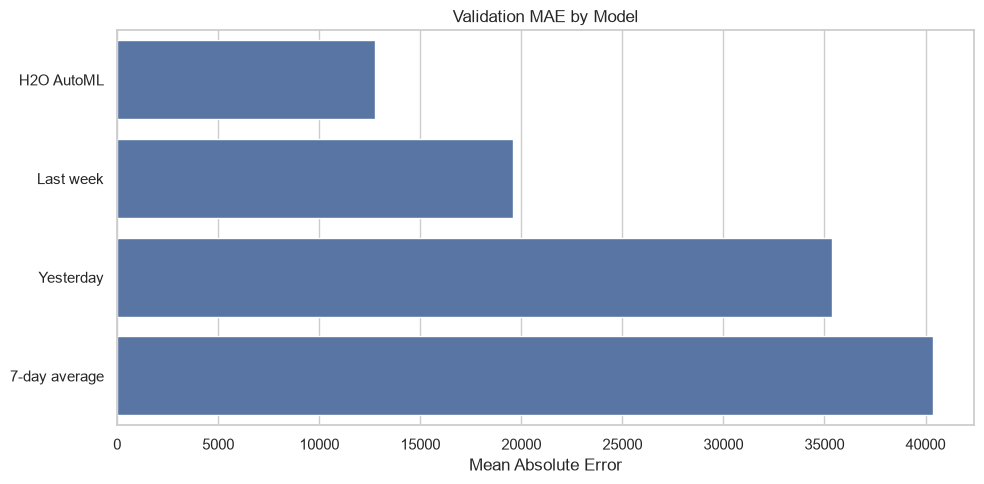

In [31]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=scores_df,
    x="MAE",
    y="model",
)

plt.title("Validation MAE by Model")
plt.xlabel("Mean Absolute Error")
plt.ylabel("")
plt.tight_layout()
plt.show()

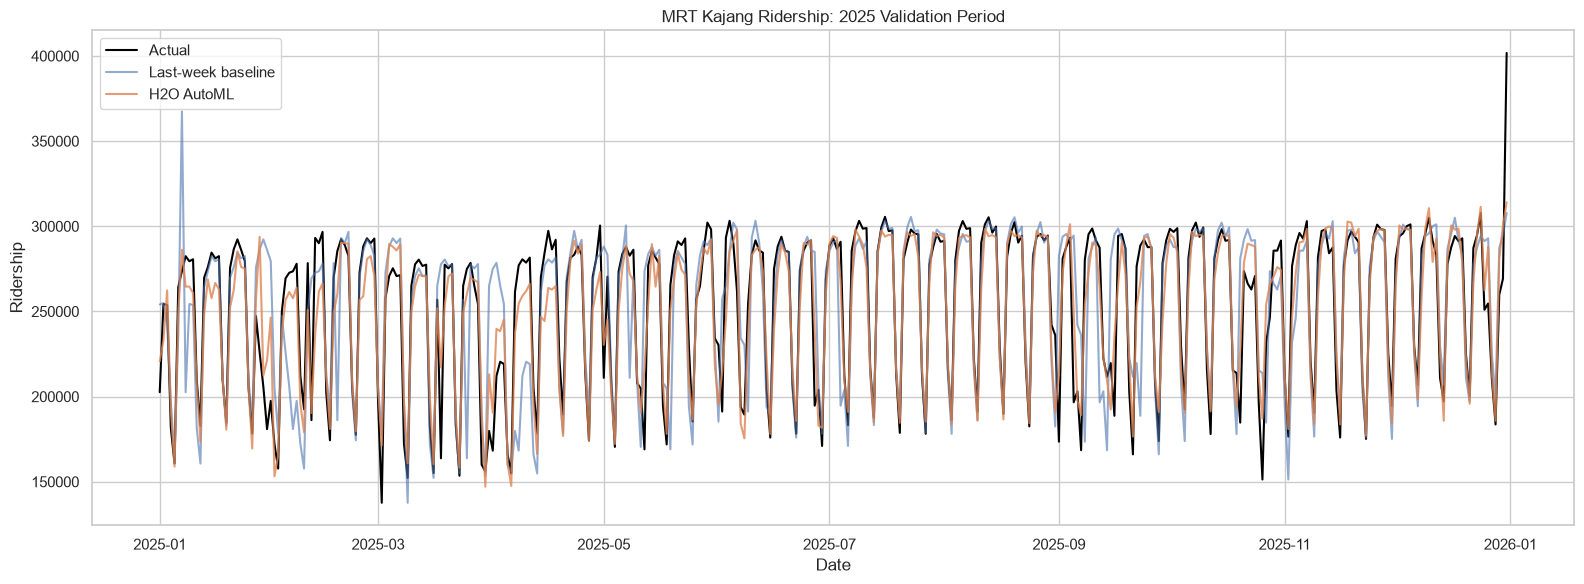

In [32]:
plt.figure(figsize=(16, 6))

plt.plot(
    validation_results.index,
    validation_results["actual"],
    label="Actual",
    color="black",
    linewidth=1.5,
)

plt.plot(
    validation_results.index,
    validation_results["last_week"],
    label="Last-week baseline",
    alpha=0.6,
)

plt.plot(
    validation_results.index,
    validation_results["h2o_automl"],
    label="H2O AutoML",
    alpha=0.8,
)

plt.title("MRT Kajang Ridership: 2025 Validation Period")
plt.xlabel("Date")
plt.ylabel("Ridership")
plt.legend()
plt.tight_layout()
plt.show()

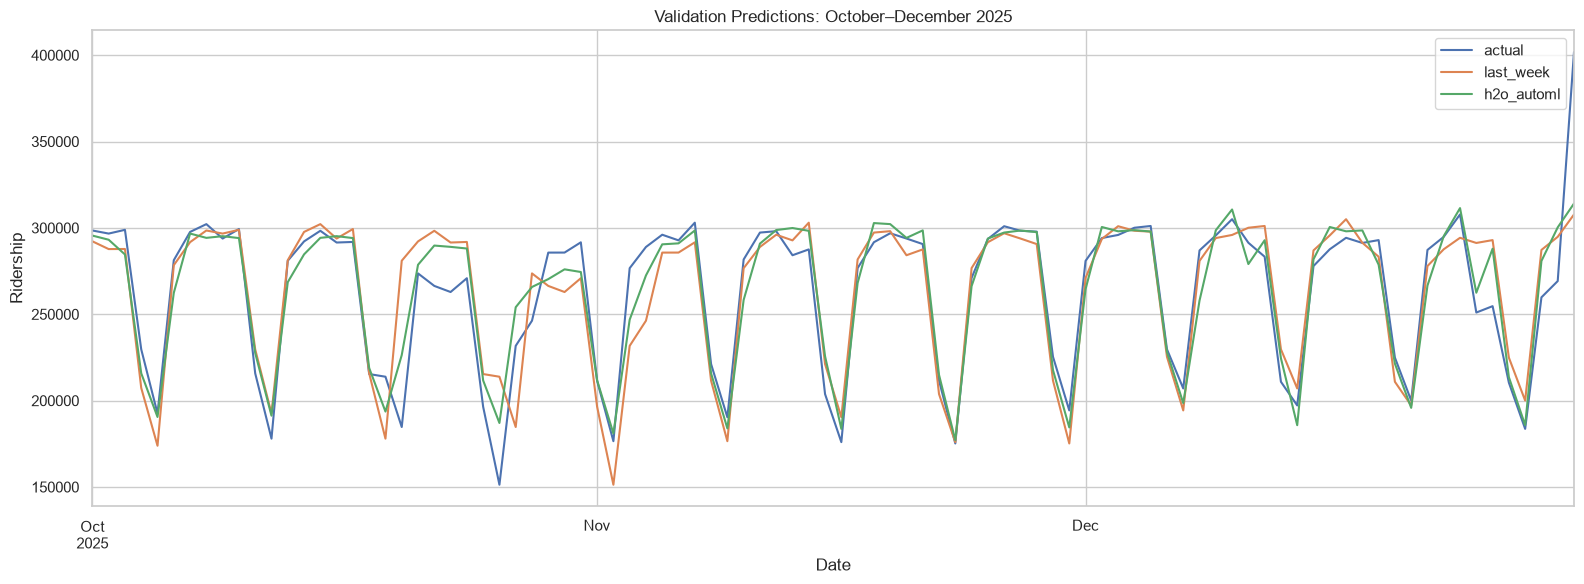

In [35]:
validation_results.loc["2025-10-01":"2025-12-31", [
    "actual",
    "last_week",
    "h2o_automl",
]].plot(figsize=(16, 6))

plt.title("Validation Predictions: October–December 2025")
plt.xlabel("Date")
plt.ylabel("Ridership")
plt.tight_layout()
plt.show()

In [36]:
validation_results["h2o_error"] = (
    validation_results["actual"]
    - validation_results["h2o_automl"]
)

validation_results["h2o_absolute_error"] = (
    validation_results["h2o_error"].abs()
)

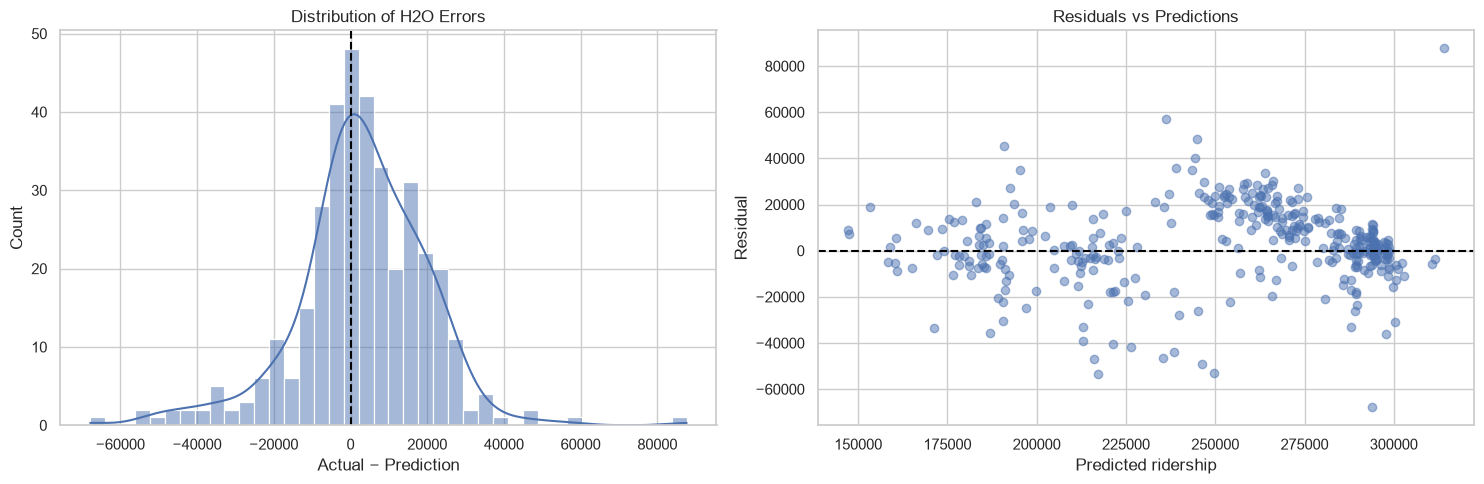

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    validation_results["h2o_error"],
    bins=40,
    kde=True,
    ax=axes[0],
)

axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Distribution of H2O Errors")
axes[0].set_xlabel("Actual − Prediction")

axes[1].scatter(
    validation_results["h2o_automl"],
    validation_results["h2o_error"],
    alpha=0.5,
)

axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals vs Predictions")
axes[1].set_xlabel("Predicted ridership")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [38]:
worst_predictions = (
    validation_results
    .sort_values("h2o_absolute_error", ascending=False)
    .head(20)
)

display(
    worst_predictions.style.format({
        "actual": "{:,.0f}",
        "h2o_automl": "{:,.0f}",
        "last_week": "{:,.0f}",
        "h2o_error": "{:,.0f}",
        "h2o_absolute_error": "{:,.0f}",
    })
)

,actual,h2o_automl,yesterday,last_week,rolling_mean_7,is_public_holiday,h2o_error,h2o_absolute_error
date,,,,,,,,
2025-12-31 00:00:00,"401,756","314,106",269198.000000,"307,763",248062.285714,0,"87,650","87,650"
2025-01-28 00:00:00,"225,941","293,816",247287.000000,"286,499",253613.428571,0,"-67,875","67,875"
2025-02-12 00:00:00,"293,164","236,268",186156.000000,"272,721",241923.714286,0,"56,896","56,896"
2025-03-18 00:00:00,"163,765","217,125",256877.000000,"277,662",243767.142857,1,"-53,360","53,360"
2025-09-05 00:00:00,"196,656","249,581",293304.000000,"294,560",258351.714286,1,"-52,925","52,925"
2025-01-31 00:00:00,"197,467","246,378",180906.000000,"279,584",217570.000000,0,"-48,911","48,911"
2025-06-03 00:00:00,"293,277","244,927",191199.000000,"264,906",258115.142857,0,"48,350","48,350"
2025-05-12 00:00:00,"169,019","216,040",204714.000000,"273,471",260953.714286,1,"-47,021","47,021"
2025-09-16 00:00:00,"188,728","235,332",219663.000000,"295,291",260997.571429,1,"-46,604","46,604"


In [39]:
holiday_scores = []

for holiday_value, group in validation_results.groupby(
    "is_public_holiday"
):
    day_type = (
        "Public holiday"
        if holiday_value == 1
        else "Normal day"
    )

    for model_name, prediction_column in {
        "Last week": "last_week",
        "H2O AutoML": "h2o_automl",
    }.items():
        metrics = calculate_metrics(
            group["actual"],
            group[prediction_column],
        )

        holiday_scores.append({
            "day_type": day_type,
            "model": model_name,
            "observations": len(group),
            **metrics,
        })

holiday_scores_df = pd.DataFrame(holiday_scores)

display(
    holiday_scores_df.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "WMAPE (%)": "{:.2f}",
    })
)

,day_type,model,observations,MAE,RMSE,WMAPE (%)
0,Normal day,Last week,344,"16,078","27,065",6.24
1,Normal day,H2O AutoML,344,"11,735","16,008",4.56
2,Public holiday,Last week,21,"76,979","82,288",38.85
3,Public holiday,H2O AutoML,21,"29,382","33,304",14.83


,variable,relative_importance,scaled_importance,percentage
0,lag_7,2.101709e+13,1.000000,0.351386
1,lag_28,9.111392e+12,0.433523,0.152334
2,lag_1,8.589137e+12,0.408674,0.143602
3,lag_14,7.222816e+12,0.343664,0.120759
4,rolling_mean_7,4.870764e+12,0.231753,0.081435
5,rolling_std_7,3.160972e+12,0.150400,0.052848
6,rolling_mean_28,2.419521e+12,0.115122,0.040452
7,day_of_week,1.149832e+12,0.054709,0.019224
8,month,4.261566e+11,0.020277,0.007125
9,is_holiday_pjy,3.873035e+11,0.018428,0.006475


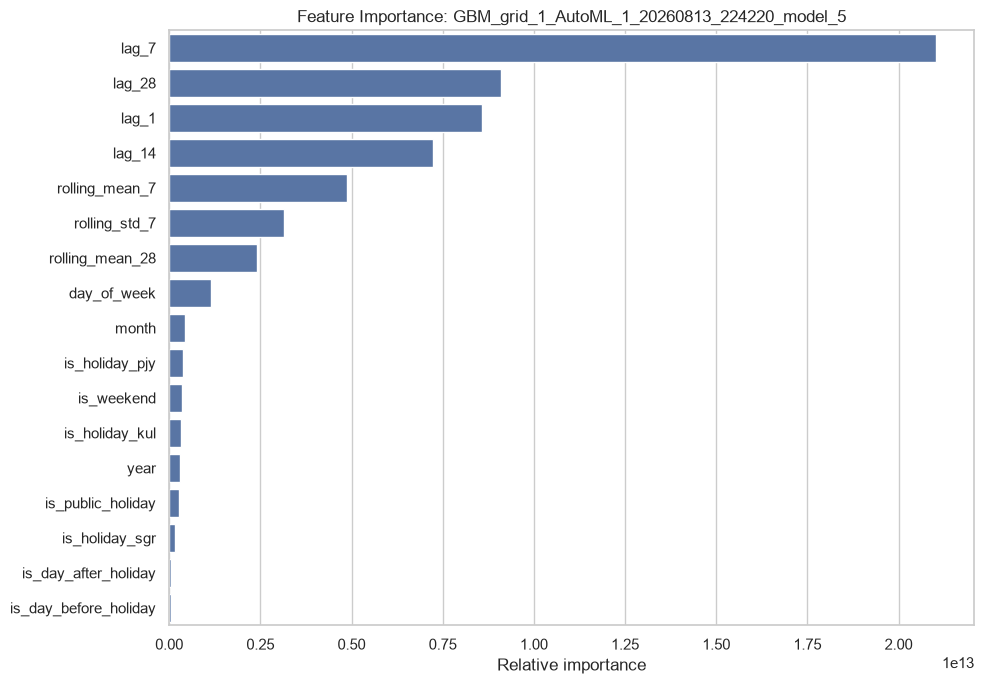

In [40]:
try:
    variable_importance = leader.varimp(use_pandas=True)

    display(variable_importance.head(20))

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=variable_importance.head(20),
        x="relative_importance",
        y="variable",
    )

    plt.title(f"Feature Importance: {leader.model_id}")
    plt.xlabel("Relative importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

except Exception as error:
    print(
        "Direct variable importance is unavailable "
        "for this model type."
    )
    print(error)